[18343.573, 18584.51, 18277.757, 18545.35, 18543.34, 18682.741, 18414.352, 18423.978, 18118.541, 18458.826, 18470.619, 18374.297, 18363.14, 18278.09, 18290.812, 18235.419, 18540.339, 18337.83, 18295.761, 18321.1, 18178.405, 18372.624, 18352.905, 18316.642, 18287.398, 18356.868, 18364.227, 18347.794, 18394.032, 18360.737, 18466.911, 18386.042, 18336.359, 18472.78, 18463.501, 18291.364, 18402.964, 18289.537, 18302.073, 18567.179]


(array([ 1.,  1.,  4., 10., 10.,  3.,  5.,  4.,  1.,  1.]),
 array([18118.541, 18174.961, 18231.381, 18287.801, 18344.221, 18400.641,
        18457.061, 18513.481, 18569.901, 18626.321, 18682.741]),
 <BarContainer object of 10 artists>)

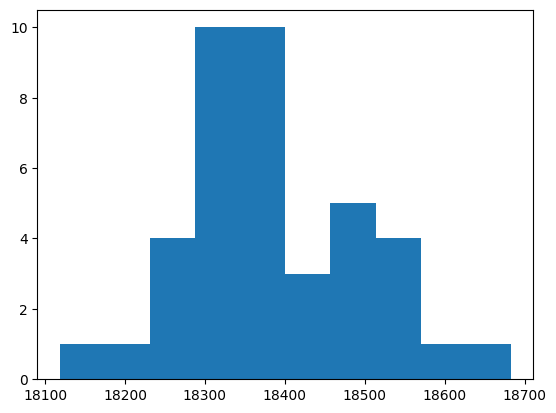

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math


prefix = "../results/"
instance = "pg_duckdb"
postfix = "_03_select.dat"
f = prefix + instance + postfix

t = []
with open(f, 'r') as file:
    for line in file:
        clear = line.strip()
        if clear:
            clear_dot = clear.replace(',', '.')
            t.append(float(clear_dot))
print(t)
plt.hist(t)

In [2]:
test_normal = stats.normaltest(t)
test_shapiro = stats.shapiro(t)
# print(test_normal, test_shapiro, sep = '\n')
print("Тест на нормальность данных: ", end='')
if test_normal[1] > 0.05 or test_shapiro[1] > 0.05:
    print("ПРОЙДЕН")
else:
    print("НЕ ПРОЙДЕН")

Тест на нормальность данных: ПРОЙДЕН


In [3]:
mean = np.mean(t)
std = np.std(t, ddof=1)
quality = (std / mean) * 100
print(f"Среднее: {mean}\nСтандартное отклонение: {std}\nОтношение std/mean (%): {quality}")

Среднее: 18380.267925
Стандартное отклонение: 113.44787300022965
Отношение std/mean (%): 0.6172264379559073


In [4]:
interval = stats.t.ppf(0.975, df=len(t)-1)*stats.sem(t)
print(f"Доверительный интервал: {interval}")

Доверительный интервал: 36.28238998513964


### Округление
- Погрешность: 40 (мс)
- Среднее: 18380 (мс)
### Итог
- Результирующее значение: 18380 ± 40 (мс)